In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi

# imports for making probe
import pyTEMlib.probe_tools as pt
import pyTEMlib.image_tools as it

# imports for making structures
from ase.io import read
from ase import Atoms
from ase.build import bulk

In [27]:
# By Austin Houston
# Date: 02/28/2024
# Updated: 03/19/2026

def sub_pix_gaussian(size=10, sigma=0.2, dx=0.0, dy=0.0):
    # returns sub-pix shifted gaussian
    coords = np.arange(size) - (size - 1) / 2.0
    x, y = np.meshgrid(coords, coords)
    g = np.exp(-(((x + dx) ** 2 + (y + dy) ** 2) / (2 * sigma**2)))
    g /= g.max()
    return g

def create_pseudo_potential(xtal, pixel_size, sigma, bounds, atom_frame=11):
    # Create empty image
    x_min, x_max = bounds[0], bounds[1]
    y_min, y_max = bounds[2], bounds[3]
    pixels_x = int((x_max - x_min) / pixel_size)
    pixels_y = int((y_max - y_min) / pixel_size)
    potential_map = np.zeros((pixels_x, pixels_y))
    padding = atom_frame  # to avoid edge effects
    potential_map = np.pad(potential_map, padding, mode='constant', constant_values=0.0)

    # Map of atomic numbers - i.e. scattering intensity
    atomic_numbers = xtal.get_atomic_numbers()
    positions = xtal.get_positions()[:, :2]

    mask = ((positions[:, 0] >= x_min) & (positions[:, 0] < x_max) & (positions[:, 1] >= y_min) & (positions[:, 1] < y_max))
    positions = positions[mask]
    atomic_numbers = atomic_numbers[mask]

    for pos, atomic_number in zip(positions, atomic_numbers):
        x,y = np.round(pos/pixel_size)
        dx,dy = pos - np.round(pos)
  
        single_atom = sub_pix_gaussian(size=atom_frame, sigma=sigma, dx=dx, dy=dy) * atomic_number
        potential_map[int(x+padding+dx-padding//2-1):int(x+padding+dx+padding//2),int(y+padding+dy-padding//2-1):int(y+padding+dy+padding//2)] += single_atom
    potential_map = potential_map[padding:-padding, padding:-padding]
    normalized_map = potential_map / np.max(potential_map)

    return normalized_map

def get_probe(ab, potential):
    size_x, size_y = potential.shape
    probe, A_k, chi  = pt.get_probe(ab, size_x, size_y, verbose= True)

    return probe

def poisson_noise(image, counts = 1e9):
    # Normalize the image
    image = image - image.min()
    image = image / image.sum()
    noisy_image = np.random.poisson(image * counts)
    noisy_image = noisy_image - noisy_image.min()
    noisy_image = noisy_image / noisy_image.max()

    return noisy_image


def lowfreq_noise(image, noise_level=0.1, freq_scale=0.1):
    size_x, size_y = image.shape

    noise = np.random.normal(0, noise_level, (size_x, size_y))
    noise_fft = np.fft.fft2(noise)

    # Create a frequency filter that emphasizes low frequencies
    x_freqs = np.fft.fftfreq(size_x)
    y_freqs = np.fft.fftfreq(size_y)
    freq_filter = np.outer(np.exp(-np.square(x_freqs) / (2 * freq_scale**2)),
                           np.exp(-np.square(y_freqs) / (2 * freq_scale**2)))

    # Apply the frequency filter to the noise in the frequency domain
    filtered_noise_fft = noise_fft * freq_filter
    noisy_image = np.fft.ifft2(filtered_noise_fft).real
    noisy_image = noisy_image - noisy_image.min()
    noisy_image = noisy_image / noisy_image.max()
    return noisy_image



In [38]:
# params
size = 1024

dwell_time = 100e-6
fov = 200 # angstrom
edge_crop = 20
beam_current = 100 # pA?  unsure
blur_noise_level = float(0.5)

In [39]:
# get probe
ab = pt.get_target_aberrations("Spectra300", 200000)
ab['acceleration_voltage'] = 200e3 # eV
ab['FOV'] = fov /10 # nm
ab['convergence_angle'] = 30 # mrad
ab['wavelength'] = it.get_wavelength(ab['acceleration_voltage'])


In [40]:
# create sample
# oversized so we can induce drift
sample_fov = (fov*1.5, fov*1.5, fov*0.5)  # angstroms
grain_size = 15  # average, used to get n_grains
empty_grains = 0.10  # 10% empty grains
lattice_constant = 4.08
desired_angles = [(0, 0, 0), (60, 0, 0), (45,45,45)]

# Create gold supercell
gold_bulk = bulk('Au', 'fcc', a=lattice_constant)
repeat_bounds = np.max(sample_fov)
repeat_factors = (int(repeat_bounds/lattice_constant), int(repeat_bounds/lattice_constant), int(repeat_bounds/lattice_constant))
supercell = gold_bulk.repeat(repeat_factors)

# Generate grain centers
n_grains = sample_fov[0] * sample_fov[1] // (4/3 * np.pi * grain_size**2)
n_grains = np.max([1, int(n_grains)])
grain_centers = np.random.rand(n_grains, 3) * np.array(sample_fov)
vor = Voronoi(grain_centers[:, :2])

# Determine which grains are empty
n_empty = int(n_grains * empty_grains)
empty_grain_indices = set(np.random.choice(n_grains, n_empty, replace=False))

# Generate rotation angles for each grain
grain_angles = []
for i in range(n_grains):
    if i < len(desired_angles):
        grain_angles.append(desired_angles[i])
    else:
        grain_angles.append(tuple(np.random.rand(3) * 360))

def rotation_matrix(alpha, beta, gamma):
    """Create rotation matrix from Euler angles (degrees)"""
    a, b, g = np.radians([alpha, beta, gamma])
    Rz = np.array([[np.cos(a), -np.sin(a), 0],[np.sin(a), np.cos(a), 0],[0, 0, 1]])
    Ry = np.array([[np.cos(b), 0, np.sin(b)],[0, 1, 0],[-np.sin(b), 0, np.cos(b)]])
    Rx = np.array([[1, 0, 0],[0, np.cos(g), -np.sin(g)],[0, np.sin(g), np.cos(g)]])
    return Rz @ Ry @ Rx

# Process each grain
all_positions = []
all_grain_labels = []
for grain_idx in range(n_grains):
    if grain_idx in empty_grain_indices:
        continue
    
    # Get rotation for this grain
    angles = grain_angles[grain_idx]
    R = rotation_matrix(*angles)
    positions = supercell.get_positions().copy()
    positions -= positions.mean(axis=0)
    positions = positions @ R.T
    positions += grain_centers[grain_idx]
    mask_fov = ((positions[:, 0] >= 0) & (positions[:, 0] < sample_fov[0]) &
                (positions[:, 1] >= 0) & (positions[:, 1] < sample_fov[1]) &
                (positions[:, 2] >= 0) & (positions[:, 2] < sample_fov[2]))
    positions = positions[mask_fov]
    
    # Assign to nearest grain center (Voronoi)
    distances = np.linalg.norm(positions[:, np.newaxis, :] - grain_centers[np.newaxis, :, :], axis=2)
    closest_grain = np.argmin(distances, axis=1)
    mask_voronoi = (closest_grain == grain_idx)
    grain_positions = positions[mask_voronoi]
    all_positions.append(grain_positions)
    all_grain_labels.extend([grain_idx] * len(grain_positions))

# Combine all atoms
all_positions = np.vstack(all_positions)
all_grain_labels = np.array(all_grain_labels)
xtal = Atoms('Au' * len(all_positions), positions=all_positions)

# create potential
pixel_size = fov / size
edge = 2 * edge_crop * pixel_size
frame = (0,fov+edge,0,fov+edge) # limits of the image in angstroms
potential = create_pseudo_potential(xtal, pixel_size, sigma=1, bounds=frame, atom_frame=11)

# create probe
probe, A_k, chi = pt.get_probe(ab, size+2*edge_crop, size+2*edge_crop, verbose=True)

# create image
psf_shifted = np.fft.ifftshift(probe)
image = np.fft.ifft2(np.fft.fft2(potential) * np.fft.fft2(psf_shifted))
image = np.absolute(image)
image = image[edge_crop:-edge_crop, edge_crop:-edge_crop]

# add shot noise
scan_time = dwell_time * size * size
counts = scan_time * (beam_current * 1e-12) / (1.602e-19) / 100
noisy_image = poisson_noise(image, counts=counts)

# add gaussian blob-like noise
blur_noise = lowfreq_noise(noisy_image, noise_level=0.1, freq_scale=.5)
noisy_image += blur_noise * blur_noise_level

sim_im = np.array(noisy_image, dtype=np.float32)


Acceleration voltage 200.0kV  => wavelength 2.51pm


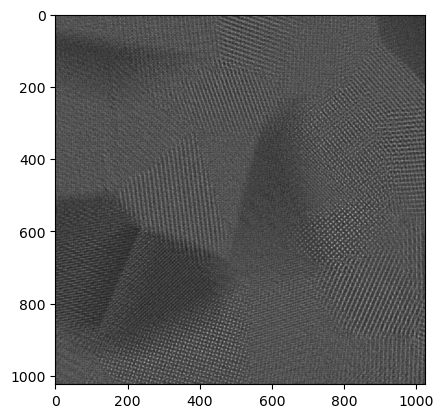

In [41]:
plt.figure()
plt.imshow(sim_im, cmap='gray')

### Now the new stuff

In [81]:
# params
size = 1024

dwell_time = 100e-6
fov = 200 # angstrom
edge_crop = 20
beam_current = 1000 # pA?  unsure
blur_noise_level = float(0.1)

In [94]:
# ── Nanoparticle parameters ─────────────────────────────────────────────────
particle_radius   = 16.0      # Angstroms, mean radius
radius_std        = 2.0      # randomize size a bit
aspect_ratio      = 0.4      # z_radius = aspect_ratio * xy_radius (flat pancake)
min_separation    = 3.0      # minimum gap between particle surfaces (Angstroms)
n_particles       = 40       # how many particles to try to place
max_attempts      = 500      # attempts to place each particle without overlap

bulk_types = {
    'Au':  bulk('Au', 'fcc', a=4.08),
    'Pt':  bulk('Pt', 'fcc', a=3.92),
    'Fe':  bulk('Fe', 'bcc', a=2.87),
}
bulk_names = list(bulk_types.keys())

desired_angles = [(0, 0, 0), (60, 0, 0), (45, 45, 45)]

def rotation_matrix(alpha, beta, gamma):
    a, b, g = np.radians([alpha, beta, gamma])
    Rz = np.array([[np.cos(a), -np.sin(a), 0], [np.sin(a),  np.cos(a), 0], [0, 0, 1]])
    Ry = np.array([[np.cos(b), 0,  np.sin(b)], [0, 1, 0],                  [-np.sin(b), 0, np.cos(b)]])
    Rx = np.array([[1, 0, 0], [0, np.cos(g), -np.sin(g)],                  [0, np.sin(g), np.cos(g)]])
    return Rz @ Ry @ Rx

# ── Place particle centers with exclusion zone ──────────────────────────────
placed_centers  = []
placed_particles = []
particle_records = []   # <-- NEW: one entry per placed particle

for _ in range(max_attempts * n_particles):
    if len(placed_particles) >= n_particles:
        break

    radius = np.random.normal(particle_radius, radius_std)
    radius = np.clip(radius, 3.0, None)

    margin = radius + 2.0
    cx = np.random.uniform(margin, sample_fov[0] - margin)
    cy = np.random.uniform(margin, sample_fov[1] - margin)
    cz = sample_fov[2] * 0.5

    too_close = False
    for (px, py, pr) in placed_centers:
        dist = np.sqrt((cx - px)**2 + (cy - py)**2)
        if dist < (radius + pr + min_separation):
            too_close = True
            break
    if too_close:
        continue

    placed_centers.append((cx, cy, radius))
    btype  = np.random.choice(bulk_names)
    i      = len(placed_particles)
    angles = desired_angles[i] if i < len(desired_angles) else tuple(np.random.rand(3) * 360)
    placed_particles.append((btype, np.array([cx, cy, cz]), radius, angles))

    # ── record composition from the bulk unit cell ──────────────────────
    symbols_in_bulk = bulk_types[btype].get_chemical_symbols()
    counts_dict = {}
    for s in symbols_in_bulk:
        counts_dict[s] = counts_dict.get(s, 0) + 1
    total = sum(counts_dict.values())
    composition = {s: c / total for s, c in counts_dict.items()}  # fractions

    particle_records.append({
        'center':      np.array([cx, cy]),   # 2D, Angstroms
        'radius':      radius,               # xy radius
        'btype':       btype,
        'composition': composition,          # e.g. {'Au': 1.0} or {'Fe': 0.5, 'Pt': 0.5}
    })

print(f"Placed {len(placed_particles)} particles")


# ── Carve each nanoparticle from its bulk ───────────────────────────────────
all_positions = []
all_symbols   = []

for (btype, center, radius, angles) in placed_particles:
    this_bulk = bulk_types[btype]
    a_lat     = this_bulk.cell.lengths()[0]
    z_radius  = radius * aspect_ratio

    # supercell just big enough to carve from
    rep       = int(radius * 2 / a_lat) + 3
    supercell = this_bulk.repeat((rep, rep, rep))

    R         = rotation_matrix(*angles)
    positions = supercell.get_positions().copy()
    positions -= positions.mean(axis=0)   # center at origin before rotation
    positions  = positions @ R.T

    # ellipsoidal mask (flat in z)
    r_scaled = np.sqrt(
        (positions[:, 0] / radius)**2 +
        (positions[:, 1] / radius)**2 +
        (positions[:, 2] / z_radius)**2
    )
    mask = r_scaled <= 1.0

    positions  = positions[mask] + center
    symbols    = [s for s, m in zip(supercell.get_chemical_symbols(), mask) if m]

    all_positions.append(positions)
    all_symbols.extend(symbols)

all_positions = np.vstack(all_positions)
xtal = Atoms(symbols=all_symbols, positions=all_positions)

# ── Rest is unchanged ────────────────────────────────────────────────────────
pixel_size  = fov / size
edge        = 2 * edge_crop * pixel_size
frame       = (0, fov+edge, 0, fov+edge)
potential   = create_pseudo_potential(xtal, pixel_size, sigma=1, bounds=frame, atom_frame=11)
probe, A_k, chi = pt.get_probe(ab, size+2*edge_crop, size+2*edge_crop, verbose=True)

psf_shifted = np.fft.ifftshift(probe)
image = np.fft.ifft2(np.fft.fft2(potential) * np.fft.fft2(psf_shifted))
image = np.absolute(image)
image = image[edge_crop:-edge_crop, edge_crop:-edge_crop]

scan_time  = dwell_time * size * size
counts     = scan_time * (beam_current * 1e-12) / (1.602e-19)
noisy_image = poisson_noise(image, counts=counts)
blur_noise  = lowfreq_noise(noisy_image, noise_level=0.1, freq_scale=.1)
noisy_image += blur_noise * blur_noise_level
sim_im = np.array(noisy_image, dtype=np.float32)

Placed 40 particles
Acceleration voltage 200.0kV  => wavelength 2.51pm


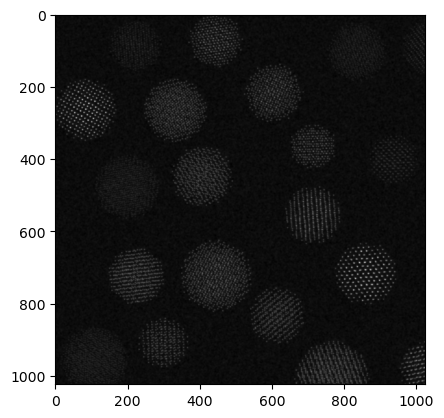

In [95]:
plt.figure()
plt.imshow(sim_im, cmap='gray')

In [108]:
def get_spectrum(mode, position, particle_records, noise_scale=0.05):
    px, py = position

    for rec in particle_records:
        cx, cy = rec['center']
        r      = rec['radius']
        if (px - cx)**2 + (py - cy)**2 <= r**2:
            raw = {
                el: np.clip(frac + np.random.normal(0, noise_scale * 0.1), 0, None)
                for el, frac in rec['composition'].items()
            }
            total = sum(raw.values())
            return {el: v / total for el, v in raw.items()}  # normalized

    all_elements = set()
    for rec in particle_records:
        all_elements.update(rec['composition'].keys())
    raw = {el: np.abs(np.random.normal(0, noise_scale)) for el in all_elements}
    total = sum(raw.values())
    return {el: v / total for el, v in raw.items()}  # also normalized, but near-random ratios

{'Pt': 0.11333144394645579,
 'Au': 0.49962871511577295,
 'Fe': 0.3870398409377712}

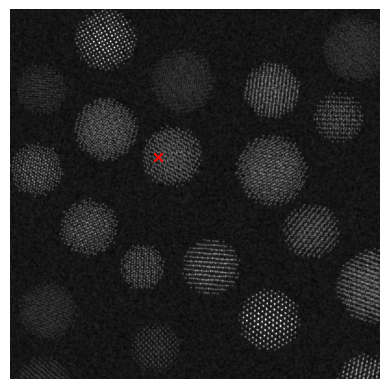

In [113]:
beam_pos = [0.4, 0.4]

plt.figure()
plt.imshow(sim_im.T, cmap='gray', vmax=0.6)
plt.scatter(beam_pos[0]*size, beam_pos[1]*size, color='red', marker='x')
plt.axis('off')

quant = get_spectrum('EDS', (beam_pos[0]*size, beam_pos[1]*size), particle_records)
quant